# Module 7: Pandas Data Structures


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

## Introduction
Pandas is a powerful Python library for data analysis, and offers flexible and efficient tools to work with structured data. In this module, you will explore the two core data structures, Series and DataFrame, which allow you to store and manipulate one-dimensional and two-dimensional data. You will practice reading from and writing to CSV files, as well as applying filtering and selection techniques to explore, clean, and transform datasets. By the end of this module, you will be able to use Pandas to efficiently organize, access, and analyze data stored in CSV format.

## Learning Objectives
- Explain and manipulate the Pandas data structures: Series and DataFrame.  
- Apply basic filtering, selection, and indexing techniques to analyze data.  
- Read, write, and save CSV files using Pandas.  

## Reading
- [Chapter 5](https://wesmckinney.com/book/pandas-basics)

In seismology, the farther away an earthquake is from a receiver, the more time there is between the arrivals of the P and S waves. You can use the difference between the arrival times of the two waves to calculate the distance to the earthquake source, if we know the velocities of the waves through the Earth. So first we need to know how these two waves behave. There are plenty of data on earthquakes and the arrival times of different waves.

Here is some additional information - https://www.iris.edu/hq/inclass/animation/traveltime_curves_how_they_are_created

Let's take a look at an example file. We can look at the first 10 lines in a file like this:

In [2]:
open('data/DeltaTime.txt').readlines()[0:10]

['https://earthquake.usgs.gov/learn/topics/ttgraph.php\n',
 'Delta Time of P  S-P Time\n',
 '  Deg   M   S     M   S\n',
 '  0.0   0   5.4   0   4.0\n',
 '  0.5   0  10.6   0   7.8\n',
 '  1.0   0  17.7   0  13.5\n',
 '  1.5   0  24.6   0  19.0\n',
 '  2.0   0  31.4   0  24.4\n',
 '  2.5   0  38.3   0  29.9\n',
 '  3.0   0  45.2   0  35.4\n']

The first line in our dataset contains words, so we can't read it with **np.loadtxt**. One strategy to remove the text would be to edit the text file, but instead let's up our game and use the powerful **Pandas** package.

## The Power of Pandas

**Pandas** allows us to read in more complicated data file formats than **NumPy**, and wrangle the data in powerful ways. It also provides many useful data analysis tools.

There are two basic data structures in Pandas, **DataFrame**, which is essentially a spreadsheet with multiple columns, while the **Series** is a single column of data.

The DeltaTime file includes the website where the original data are from at the top of the file, a description in line 2 of what the data are about in general, and then some column headers in line 3. This kind of file does not play nicely with **np.loadtxt( )**, but we can use the **Pandas** function, **read_csv( )** to read in the datafile. This function not only reads in 'comma separated variable' files (.csv), but also other data formats once we tell it how the file is delimited.

First we must import **Pandas** into the notebook.

In [3]:
import pandas as pd

A few things you need to let **Pandas** know.  

- We need to skip the first two rows. We use the keyword argument **skiprows=2** to do that. 
- **pd.read_csv( )** reads 'comma separated variables' by default but this file is _whitespace_ delimited. _whitespace_ is either spaces or tabs. The keyword argument **delim_whitespace=True** will split on white space.
- the _header_ is in the third row; this is the row with the column names in it. Python starts counting from zero, but we skipped two rows, so **header=0** will read in the first row after the skipped rows as the header. 
- fun fact: with skiprows we don't need the header statement, but you need to know what it is. For example, you could use **header=2** instead of **skiprows**. Why 2? because **header** starts with 0 as the default.   


In [4]:
# we specify the path of the file (relative to our current directory), then all the other arguments.
DeltaTimeData = pd.read_csv('data/DeltaTime.txt',delim_whitespace=True,skiprows=2,header=0)

DeltaTimeData.head() # this is "panda-ish" for looking at the "head" of the object we read in.

/var/folders/d6/gwgxc4k54kn3257svv59qtgh0000gp/T/ipykernel_7443/2909015011.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  DeltaTimeData = pd.read_csv('data/DeltaTime.txt',delim_whitespace=True,skiprows=2,header=0)


,Deg,M,S,M.1,S.1
0,0.0,0,5.4,0,4.0
1,0.5,0,10.6,0,7.8
2,1.0,0,17.7,0,13.5
3,1.5,0,24.6,0,19.0
4,2.0,0,31.4,0,24.4


**DeltaTimeData** is now a Pandas **DataFrame**.  

So what is a **DataFrame**? It is a new data container that is more sophisticated than any we have learned about so far (**lists, tuples, sets, dictionaries, arrays**).   
It has named columns (like an Excel spreadsheet) and identifies the rows by _indices_ starting with 0. 

The file we read in included column headers and **Pandas** knows which line they were in (after the header or skiprows arguments).  

If we want to be sure, we can use the **DataFrame.columns** attribute on the DeltaTimeData DataFrame:


In [5]:
DeltaTimeData.columns

Index(['Deg', 'M', 'S', 'M.1', 'S.1'], dtype='object')

In [6]:
DeltaTimeData.index

RangeIndex(start=0, stop=116, step=1)

In [7]:
DeltaTimeData.dtypes

Deg    float64
M        int64
S      float64
M.1      int64
S.1    float64
dtype: object

Notice that a **DataFrame** is of type _object_, similar to one of the **NumPy** array types that mixed data types we briefly encountered before. Let's explore these objects with Pandas DataFrames.  

We see that the columns of **DeltaTimeData** are: 
- "Deg": the degrees away from the source (the angle from the center of the Earth)
- "M": the time of the P wave arrival in minutes
- "S": the P wave arrival in seconds (added to the minutes)
- "M.1": the difference in the P and S wave arrival time in minutes and 
- "S.1" the seconds for the time difference in the P and S waves.  

Each one of these columns is a **Pandas Series.** So **DataFrames** are like Excel spreadsheets and **Series** are one column of the spreadsheet.  

We can change the column names by setting **DataFrame.columns** to a list with the new (more meaningful) column names: 

In [8]:
# Change the column names to more meaningful names
DeltaTimeData.columns = ['Degrees','P_wave_minutes','P_wave_seconds','S-P_minutes','S-P_seconds']
DeltaTimeData.head()

,Degrees,P_wave_minutes,P_wave_seconds,S-P_minutes,S-P_seconds
0,0.0,0,5.4,0,4.0
1,0.5,0,10.6,0,7.8
2,1.0,0,17.7,0,13.5
3,1.5,0,24.6,0,19.0
4,2.0,0,31.4,0,24.4


To save a DataFrame to a file, we use the **to_csv** method: 

In [9]:
# Save the dataframe to a file
DeltaTimeData.to_csv('PSArrival.csv', index=False)

Without the argument **index=False**, there is an annoying extra column with all the DataFrame's index numbers, with **index** set to False, these do not appear. You can check it out with excel or something.  

Also, there are many other file formats besides 'comma separated variable' (.csv) which can be saved using the **sep** argument. **sep** stands for "separator". For example, sep='\t' makes it a tab delimited (separated) file: 

In [10]:
DeltaTimeData.to_csv('PSArrival.txt',sep='\t', index=False)

### Back to the science

What we really want for our "science" problem is the arrival time in decimal minutes, not minutes and seconds as in this data file. We can do this by defining a new column ("P\_decimal\_minutes"), converting the seconds data to decimal minutes (by dividing by 60) and adding that to the minutes: 

In [11]:
DeltaTimeData['P_decimal_minutes'] = DeltaTimeData['P_wave_minutes'] + DeltaTimeData['P_wave_seconds']/60
DeltaTimeData.head()

,Degrees,P_wave_minutes,P_wave_seconds,S-P_minutes,S-P_seconds,P_decimal_minutes
0,0.0,0,5.4,0,4.0,0.090000
1,0.5,0,10.6,0,7.8,0.176667
2,1.0,0,17.7,0,13.5,0.295000
3,1.5,0,24.6,0,19.0,0.410000
4,2.0,0,31.4,0,24.4,0.523333


Notice how we have a new column which is the decimal minutes after the Earthquake that the P wave arrived at that angular distance (Deg).   



In [12]:
DeltaTimeData.columns

Index(['Degrees', 'P_wave_minutes', 'P_wave_seconds', 'S-P_minutes',
       'S-P_seconds', 'P_decimal_minutes'],
      dtype='object')

We would also like the time of S wave arrival, rather than the time between the S and P wave arrivals

In [13]:
DeltaTimeData['SP_decimal_minutes'] = DeltaTimeData['S-P_minutes'] + DeltaTimeData['S-P_seconds']/60 # convert delay time to decimal minutes
DeltaTimeData['S_decimal_minutes'] = DeltaTimeData['P_decimal_minutes'] + DeltaTimeData['SP_decimal_minutes'] # calculate S wave arrival time in minutes
DeltaTimeData.head()

,Degrees,P_wave_minutes,P_wave_seconds,S-P_minutes,S-P_seconds,P_decimal_minutes,SP_decimal_minutes,S_decimal_minutes
0,0.0,0,5.4,0,4.0,0.090000,0.066667,0.156667
1,0.5,0,10.6,0,7.8,0.176667,0.130000,0.306667
2,1.0,0,17.7,0,13.5,0.295000,0.225000,0.520000
3,1.5,0,24.6,0,19.0,0.410000,0.316667,0.726667
4,2.0,0,31.4,0,24.4,0.523333,0.406667,0.930000


In [14]:
DeltaTimeData['Degrees']

0        0.0
1        0.5
2        1.0
3        1.5
4        2.0
       ...  
111    101.0
112    102.0
113    103.0
114    104.0
115    105.0
Name: Degrees, Length: 116, dtype: float64

OK. Now we are ready to make a plot of our travel time and angular distances. Combining **Pandas DataFrames** with **matplotlib** turns out to be pretty simply, where we just use the name of the **Series** we want to plot as an argument in **plt.plot( )**.

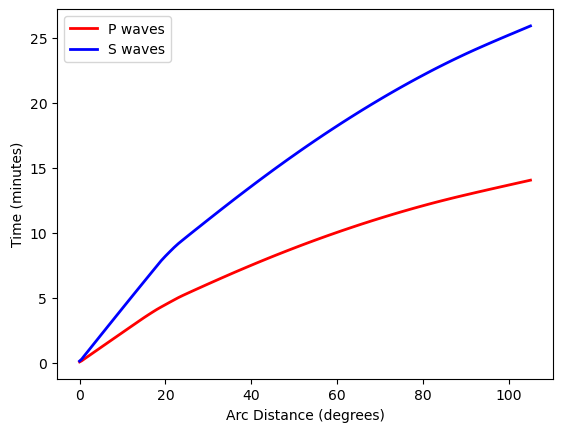

In [15]:
# plots the P wave arrival as red  lines
# notice the linewidth=2  makes the line heavier. the default is linewidth=1
plt.plot(DeltaTimeData['Degrees'].values,DeltaTimeData['P_decimal_minutes'].values,color='r',linestyle='-',linewidth=2,label='P waves')

# plots the S wave arrival as blue lines
plt.plot(DeltaTimeData['Degrees'].values,DeltaTimeData['S_decimal_minutes'].values,color='b',linestyle='-',linewidth=2,label='S waves') 

plt.xlabel('Arc Distance (degrees)') # labels the x axis
plt.ylabel('Time (minutes)') # labels the y axis
plt.legend(loc=2) # location 2 is in the upper left hand corner

Or we could plot the data as squares and triangles.

Now we have two different symbols, red triangles and blue squares. We used the **label** argument to label the symbol types and then use the **plt.legend( )** method to place the legend onto the figure.  

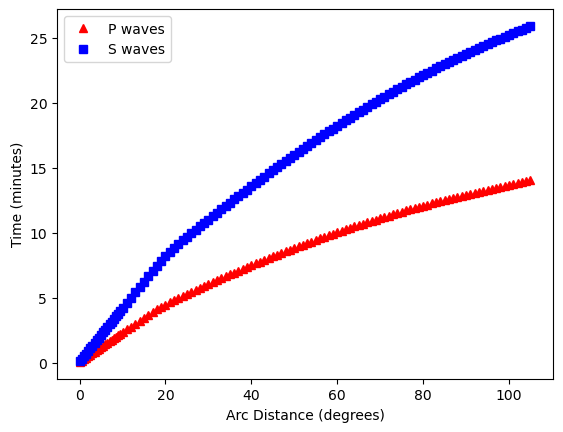

In [16]:
# plots the P wave arrival as red  triangles (^)
plt.plot(DeltaTimeData['Degrees'].values,DeltaTimeData['P_decimal_minutes'].values,color='r',linestyle='none',marker='^',label='P waves')

# plots the S wave arrival as blue squares (s)
plt.plot(DeltaTimeData['Degrees'].values,DeltaTimeData['S_decimal_minutes'].values,color='b',linestyle='none',marker='s',label='S waves') 

plt.xlabel('Arc Distance (degrees)') # labels the x axis
plt.ylabel('Time (minutes)'); # labels the y axis
plt.legend(loc=2); # location 2 is in the upper left hand corner

In the next module, we'll use this on real P and S wave arrival data. We will calculate the time delay between the P and S wave arrival, find that time delay in our DeltaTimeData DataFrame, find the corresponding angular distance, and then calculate the actual great circle between the two points to find the location of the source.

Before we go, let's leave a nice data file to work on. We can make a **DataFrame** of our earthquake data called **EQ**.

In [17]:
velocity = np.loadtxt('data/earthquake.txt') # read in data as np array
print(velocity)

time_units = np.arange(len(velocity)) # makes a numpy array of arbitrary time units
# now I want an array that is normalized to minutes: 
minutes = time_units/1200. # sampling rate=20/sec = 1/1200 minutes

# create a pd DataFrame from the two np arrays
EQ = pd.DataFrame([minutes,velocity])
EQ.head()

[  1807.   1749.   1694. ... -14264. -14888. -15489.]


,0,1,2,3,4,5,6,7,8,9,...,25190,25191,25192,25193,25194,25195,25196,25197,25198,25199
0,0.0,0.000833,0.001667,0.0025,0.003333,0.004167,0.005,0.005833,0.006667,0.0075,...,20.991667,20.9925,20.993333,20.994167,20.995,20.995833,20.996667,20.9975,20.998333,20.999167
1,1807.0,1749.000000,1694.000000,1618.0000,1516.000000,1394.000000,1282.000,1198.000000,1077.000000,957.0000,...,-9275.000000,-10063.0000,-10806.000000,-11515.000000,-12214.000,-12915.000000,-13599.000000,-14264.0000,-14888.000000,-15489.000000


Hmmm, that doesn't look like what we really need. First, there are only two rows (minutes and velocity) and we want
two columns, not two rows. To do that, we can transpose the **DataFrame**, just like a **NumPy** array:  

In [18]:
EQ = pd.DataFrame([minutes,velocity]).transpose()
EQ.head()

,0,1
0,0.000000,1807.0
1,0.000833,1749.0
2,0.001667,1694.0
3,0.002500,1618.0
4,0.003333,1516.0


That is better, but we would really like column headers with names, not numbers so we change the column headers with the **column** attribute.    

In [19]:
EQ.columns = ['Minutes','Velocity']
EQ.head()

,Minutes,Velocity
0,0.000000,1807.0
1,0.000833,1749.0
2,0.001667,1694.0
3,0.002500,1618.0
4,0.003333,1516.0


The above can also be achieved through one step as follows. Note that a dictionary is used as the input to **pd.DataFrame()**. The dictionary keys are column names. The dictionary values are the numpy arrays for each column.

In [20]:
EQ = pd.DataFrame({
    'Minutes':minutes,
    'Velocity':velocity,
})
EQ.head()

,Minutes,Velocity
0,0.000000,1807.0
1,0.000833,1749.0
2,0.001667,1694.0
3,0.002500,1618.0
4,0.003333,1516.0


And now we can save our DataFrames as a file.  

In [21]:
EQ.to_csv('data/minutes_velocity.csv',index=None)

# by setting index to None, we don't have the indices as a column in the datafile. 
DeltaTimeData.to_csv('data/DeltaTimeData.csv',index=None)

Returning to our original seismogram from Module 6:

    Minutes  Velocity
0  0.000000    1807.0
1  0.000833    1749.0
2  0.001667    1694.0
3  0.002500    1618.0
4  0.003333    1516.0


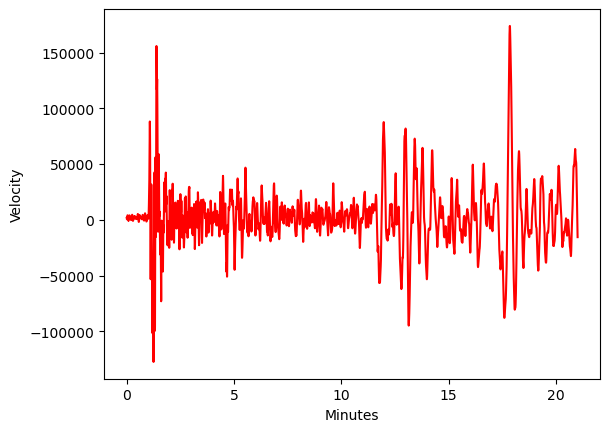

In [22]:
EQ = pd.read_csv('data/minutes_velocity.csv')
print(EQ.head())

plt.plot(EQ['Minutes'].values,EQ['Velocity'].values, c='r', ls='-') # plots as a red line
#plt.plot(EQ, 'r-') # shorter form

plt.xlabel('Minutes') # puts a label on the X axis
plt.ylabel('Velocity'); # puts a label on the Y axis

### Filtering data with Pandas

Considering our seismic record, you know that the P wave arrives in the first few minutes of the record. To find the exact time, we can filter the data to look for the maximum (either positive or negative) velocity between two time intervals, say 1 and 1.37 minutes, and take this as the P-wave arrival time.

To look only at the interval between two times, we first need to understand some more about **Pandas** data structures. Remember that the **DataFrames** are made up of columns of data (with the indices) and each Column is itself a **Series**.

We can access a particular **Series** in two ways. One is to use the **Series** name as a key (like in Dictionaries).  

In [23]:
print(EQ['Minutes'].head())

0    0.000000
1    0.000833
2    0.001667
3    0.002500
4    0.003333
Name: Minutes, dtype: float64


OR, we can use the **Series** name as an attribute of the **DataFrame**: 

In [24]:
print(EQ.Minutes.head())

0    0.000000
1    0.000833
2    0.001667
3    0.002500
4    0.003333
Name: Minutes, dtype: float64


As you can see below, both of these are identical and are _instances_ of a Pandas **Series** class: 

In [25]:
print(type(EQ['Minutes']))
print(type(EQ.Minutes))

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


Although I said that these two ways of accessing **Series** were identical, they are really only identical if there are no spaces in the column name. If you (like most Excel users) like to put spaces in your column names, then you can only use the first form.  

Let's take a closer look at one of these **Series**:

In [26]:
EQ.Minutes.head()

0    0.000000
1    0.000833
2    0.001667
3    0.002500
4    0.003333
Name: Minutes, dtype: float64

The EQ.Minutes **Series** are floating point numbers but have indices (starting with 0) so they are like arrays and lists, but are not the same thing. No worries - you can turn a **Series** into an array with this command.

In [27]:
EQ_array = EQ.Minutes.values
print(EQ_array[0:20]) # print the first 20 elements

[0.         0.00083333 0.00166667 0.0025     0.00333333 0.00416667
 0.005      0.00583333 0.00666667 0.0075     0.00833333 0.00916667
 0.01       0.01083333 0.01166667 0.0125     0.01333333 0.01416667
 0.015      0.01583333]


Or we can make it a list:  

In [28]:
EQ_list = EQ.Minutes.tolist()
print(EQ_list[0:20]) # print the first 20 elements

[0.0, 0.0008333333333333, 0.0016666666666666, 0.0025, 0.0033333333333333, 0.0041666666666666, 0.005, 0.0058333333333333, 0.0066666666666666, 0.0075, 0.0083333333333333, 0.0091666666666666, 0.01, 0.0108333333333333, 0.0116666666666666, 0.0125, 0.0133333333333333, 0.0141666666666666, 0.015, 0.0158333333333333]


You can filter the EQ **DataFrame** by placing conditions (which evaluate to **True** or **False**) on one of the **Series** (Minutes or Velocity).

The simplest syntax of a basic **Pandas** filter is: 

**DataFrame.Series\[condition\]**


The "P wave arrival" is by definition, the first wave recorded that exceeds "noise". So we need to calculate what the "noise" level is by getting the maximum and minimum values in the first part of the record, say the first minute.  

To find all the records where the series **EQ.Minutes** is less than 1, we need to set the condition to:

EQ.Minutes<1

Let's just see what that does: 



In [29]:
EQ.Minutes<1

0         True
1         True
2         True
3         True
4         True
         ...  
25195    False
25196    False
25197    False
25198    False
25199    False
Name: Minutes, Length: 25200, dtype: bool

So the **EQ.Minutes<1** condition returned another Pandas **Series** with the **EQ.Minutes Series** being evaluated for each element in the **Series**.   

If we use the returned set of booleans as the "key" in the DataFrame **EQ**, Pandas will return all the indices in the **DataFrame** for which the condition is **True**:  

In [30]:
EQ[EQ.Minutes<1]

,Minutes,Velocity
0,0.000000,1807.0
1,0.000833,1749.0
2,0.001667,1694.0
3,0.002500,1618.0
4,0.003333,1516.0
...,...,...
1195,0.995833,2857.0
1196,0.996667,2761.0
1197,0.997500,2671.0
1198,0.998333,2627.0


Notice how this is the same as our masking and filtering efforts with **Numpy** arrays that you already saw.

Now we assign this new **DataFrame** to **Noise**:

In [31]:
Noise = EQ[EQ.Minutes<1]
print(Noise.head())
print(Noise.tail())

    Minutes  Velocity
0  0.000000    1807.0
1  0.000833    1749.0
2  0.001667    1694.0
3  0.002500    1618.0
4  0.003333    1516.0
       Minutes  Velocity
1195  0.995833    2857.0
1196  0.996667    2761.0
1197  0.997500    2671.0
1198  0.998333    2627.0
1199  0.999167    2532.0


Here we created a NEW **DataFrame**, _Noise_, that is a subset of the original _EQ_ and contains only the first minute worth of data.

There are many methods for Panda **Series**. Two of these are **.max()** and **.min()**. To get the maximum and minimum values of the velocity **Series** in the first minute, we just apply **.max()** and **.min()** to the **Series**:

In [32]:
NoiseMax = Noise.Velocity.max()
print ('maximum noise value: ',NoiseMax)

NoiseMin = Noise.Velocity.min()
print ('minimum noise value: ',NoiseMin)

maximum noise value:  5912.0
minimum noise value:  -1848.0


Now we can find the first velocity that exceeds (in the absolute sense) **NoiseMax** in the **EQ** DataFrame. 

To do this, we can find the first peaks or troughs in the Velocity Series that are outside the bounds of **NoiseMax** and **NoiseMin** respectively. So, here are all the peaks and troughs in the data series that exceed the noise bounds:  

In [33]:
Peaks = EQ[EQ.Velocity > NoiseMax]
print(Peaks.head())

Troughs = EQ[EQ.Velocity < NoiseMin]
print(Troughs.head())

       Minutes  Velocity
1230  1.025000    6344.0
1231  1.025833    6991.0
1232  1.026667    7655.0
1233  1.027500    8309.0
1234  1.028333    8912.0
       Minutes  Velocity
1323  1.102500   -4090.0
1324  1.103333   -8919.0
1325  1.104167  -13595.0
1326  1.105000  -18138.0
1327  1.105833  -22528.0


We can get these both in one go by using the Pandas "or" trick, which has the general syntax of: 

**DataFrame.Series\[ (condition_1) | (condition_2) \]**

where the '|' stands for 'or'.  

While we are on the topic, other types of conditions, including 'and' and 'not'. 'and' is represented by a '&':

**DataFrame.Series\[ (condition_1) & (condition_2) \]**

which requires both conditions to be **True**, and "and not" is a '& ~':  


**DataFrame.Series\[ (condition_1) & ~(condition_2) \]**

which requires condition_1 to be **True** and condition_2 to be **False**.  

Anyway, we can get a single data frame with all the values exceeding bounds (both negative and positive) this way:  


In [34]:
PeaksandTroughs = EQ[ (EQ.Velocity>NoiseMax) | (EQ.Velocity<NoiseMin) ]
print(PeaksandTroughs.head())

       Minutes  Velocity
1230  1.025000    6344.0
1231  1.025833    6991.0
1232  1.026667    7655.0
1233  1.027500    8309.0
1234  1.028333    8912.0


So the first Velocity that exceeds the noise is a peak that arrives at 1.025 minutes.

We can make a variable named **PwaveArrival** by converting the **Series** _PeaksandTroughs.Minutes_ to an array (by using the **.values** method on the **Series**) and then selecting the first value in this array.  
    

In [35]:
PwaveArrival = PeaksandTroughs.Minutes.values[0]
PwaveArrival

1.025

After the P wave arrival, the earthquake rumbles along for a few minutes, so we need to re-characterize the noise floor, say between 5 and 10 minutes. Let's repeat the noise exercise for the period between 5 and 10 minutes. In this case, we have TWO conditions: the first being Minutes$>$5 and the second being Minutes$<$10. 


To impose two conditions, we can combine each (enclosed in parentheses) with '&':  

In [36]:
Noise2 = EQ[ (EQ.Minutes >5) & (EQ.Minutes<10) ]
print(Noise2.head()) # see, we only have data after 5 minutes
print(Noise2.tail()) # and before 10 minutes.  


       Minutes  Velocity
6001  5.000833  -15898.0
6002  5.001667  -17112.0
6003  5.002500  -18312.0
6004  5.003333  -19544.0
6005  5.004167  -20811.0
        Minutes  Velocity
11995  9.995833    9719.0
11996  9.996667   10343.0
11997  9.997500   10992.0
11998  9.998333   11599.0
11999  9.999167   12151.0


Following the same logic as before, we can find the bounds for the noise: 

In [37]:
Noise2Max = Noise2.Velocity.max()
Noise2Min = Noise2.Velocity.min()
print(Noise2Max,Noise2Min)

46816.0 -44753.0


 To find the new S wave arrival, we find the peaks and troughs that exceed the maximum and minimum values in the time between 5 and 10 minutes. First we need to filter for data after the first 10 minutes. 

In [38]:
PostP = EQ[EQ.Minutes>10]

 Now we can use our handy 'or' operator '|' like this: 

In [39]:
PeaksandTroughs2 = PostP[ (PostP.Velocity>Noise2Max) | (PostP.Velocity<Noise2Min) ]
print(PeaksandTroughs2.head())

         Minutes  Velocity
14089  11.740833  -44843.0
14090  11.741667  -45729.0
14091  11.742500  -46570.0
14092  11.743333  -47369.0
14093  11.744167  -48142.0


The S wave arrives as a trough at about 11.7 minutes into the earthquake.  

Let's retrieve that value like we did before.  

In [40]:
SwaveArrival = PeaksandTroughs2.Minutes.values[0]
SwaveArrival

11.740833333333333

So the time delay between P and S wave arrivals can be calculated as the difference in their arrival times: 


In [41]:
delayTime = SwaveArrival - PwaveArrival
delayTime

10.715833333333332

From this we see that there was a 10.7 minute delay.

If you have already taken geophysics, you probably know that seismologists have figured out the velocity of various seismic waves as a function of depth in the Earth. From this model, there is a basic look up table that specifies the delay times as a function of distance (expressed as an angle) between the source and the receiver. This model is in the file **DeltaTimeData.csv** that we already looked at and saved in the previous module.

Let's take another look at this file: 

   Degrees  P_wave_minutes  P_wave_seconds  S-P_minutes  S-P_seconds  \
0      0.0               0             5.4            0          4.0   
1      0.5               0            10.6            0          7.8   
2      1.0               0            17.7            0         13.5   
3      1.5               0            24.6            0         19.0   
4      2.0               0            31.4            0         24.4   

   P_decimal_minutes  SP_decimal_minutes  S_decimal_minutes  
0           0.090000            0.066667           0.156667  
1           0.176667            0.130000           0.306667  
2           0.295000            0.225000           0.520000  
3           0.410000            0.316667           0.726667  
4           0.523333            0.406667           0.930000  


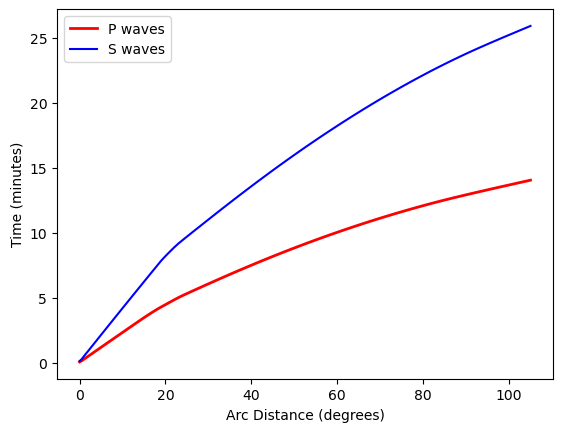

In [42]:
DeltaTimeData = pd.read_csv('data/DeltaTimeData.csv') # read this back in
print(DeltaTimeData.head())

# plots the P wave arrival as red  lines
# notice the linewidth=2  makes the line heavier. the default is linewidth=1
plt.plot(DeltaTimeData['Degrees'].values,DeltaTimeData['P_decimal_minutes'].values,'r-',label='P waves',linewidth=2)

# plots the S wave arrival as blue lines
plt.plot(DeltaTimeData['Degrees'].values,DeltaTimeData['S_decimal_minutes'].values,'b-',label='S waves') 

plt.xlabel('Arc Distance (degrees)') # labels the x axis
plt.ylabel('Time (minutes)'); # labels the y axis
plt.legend(loc=2) # location 2 is in the upper left hand corner

So, how many degrees away from the source is the receiver based on the DeltaTimeData data from the Reference Earth Model?

We can bracket the angular distance this represents by filtering the **DeltaTimeData** DataFrame for those records within, say, .2 minutes of our delay time:

In [43]:
find_delta = DeltaTimeData[
        (DeltaTimeData.SP_decimal_minutes>delayTime-.2) & 
        (DeltaTimeData.SP_decimal_minutes<delayTime+.2)] 

find_delta  # find_delta has all the records with SP_min less than 10

,Degrees,P_wave_minutes,P_wave_seconds,S-P_minutes,S-P_seconds,P_decimal_minutes,SP_decimal_minutes,S_decimal_minutes
96,86.0,12,37.0,10,31.9,12.616667,10.531667,23.148333
97,87.0,12,41.9,10,36.7,12.698333,10.611667,23.310000
98,88.0,12,46.7,10,41.4,12.778333,10.690000,23.468333
99,89.0,12,51.4,10,46.1,12.856667,10.768333,23.625000
100,90.0,12,56.1,10,50.7,12.935000,10.845000,23.780000


So according to the model, the earthquake occurred around **89 degrees** away from the receiver.   

We know the location of both the earthquake and the receiver, so we could calculate the actual separation to verify this result.

### Great Circle Distances

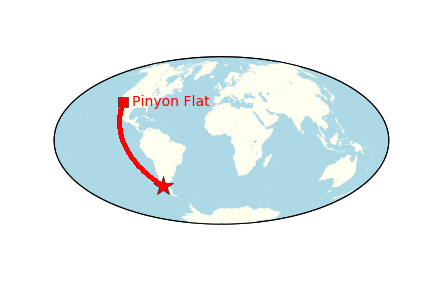

In [44]:
Image(filename='img/greatCirc.png',width=500)

First, we must calculate the angular distance (great circle distance in arc length - not kilometers) for the two points, B and C.  

We'll need to use _spherical trigonometry_ which is very useful in Earth Science because we live on a sphere. 

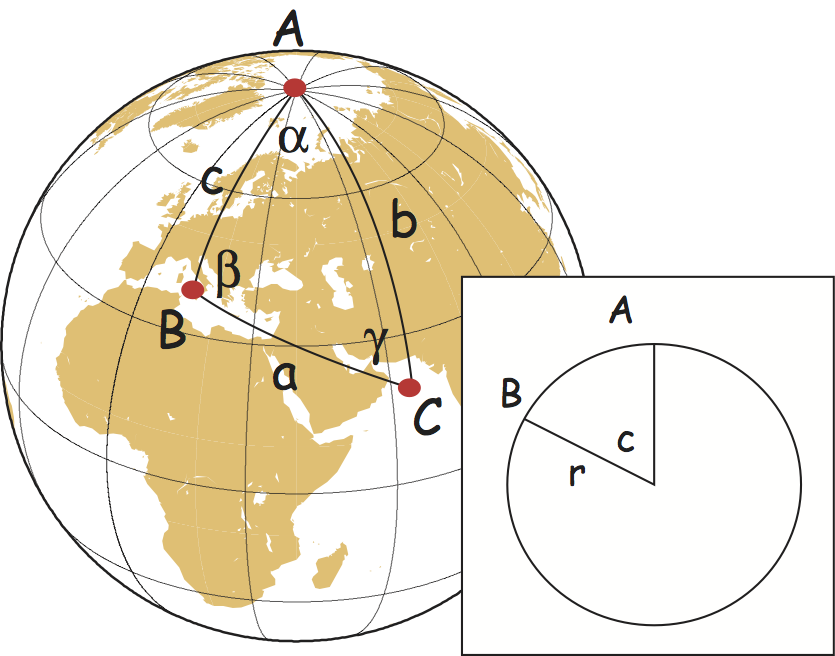

In [45]:
Image(filename='img/strig.png',width=500)

One of the laws of spherical trigonometry is the Law of Cosines: 

$\cos a = \cos b \cos c + \sin b \sin c \cos \alpha$.

In our case, $a$ is the great circle distance between points on the globe, $B$ and $C$. So to get $a$ we need to know $b, c$ and $\alpha$. $b$ and $c$ are the **co-latitudes** (90-latitude) of points B and C, respectively, and $\alpha$ is the difference in the two longitudes.

Now we have a formula, we can write a function to calculate the great circle distance from the latitudes and longitudes of the two points (lat\_1,lon\_1,lat\_2,lon\_2).

In [46]:
def colat(lat):
    return np.radians(90 - lat)

def londiff(lon1,lon2):
    return np.radians(lon2 - lon1)

def great_circle(lat_1,lon_1,lat_2,lon_2):
    """
    calculates great circle distance between two points on a globe
    Parameters:
        lat_1 : float
           latitude of first point
        lon_1 : float
            longitude of first point
        lat_2 : float
           latitude of second point
        lon_2 : float
            longitude of second point
    Returns:
        a : float
            great circle distance in degrees
    """
    
    # first, convert the latitudes to colatitudes:
    #colat_1,colat_2 = 90-lat_1, 90-lat_2
    colat_1 = colat(lat_1)
    colat_2 = colat(lat_2)
    
    # alpha is the difference betwee the two longitudes
    #alpha = lon_2-lon_1
    alpha = londiff(lon_1,lon_2)
    
    # convert degrees to radians
    #colat_1,colat_2,alpha = np.radians(colat_1),np.radians(colat_2),np.radians(alpha)
    
    # from spherical trigonometry we know that:
    cosa = np.cos(colat_1)*np.cos(colat_2)+np.sin(colat_1)*np.sin(colat_2)*np.cos(alpha)
    
    # solve for a
    a = np.arccos(cosa)# take the arc cosine of cosa
    
    # convert back to degrees!  
    return np.degrees(a) # return the great circle distance in degrees.  

In [47]:
PF_lat,PF_lon = 33.3,-115.7
EQ_lat,EQ_lon = -43.42,-73.95

Delta = great_circle(PF_lat,PF_lon,EQ_lat,EQ_lon)
print('Degrees separation between source and receiver: ',Delta)


Degrees separation between source and receiver:  85.66731577526345


Earlier, we guessed that it would be about 89 degrees. So this is pretty close.  